# 03 — Exploratory Data Analysis (M5 Deep Dive)

## Research objective

Characterise the demand structure of the **M5 dataset** *before* choosing models and before selecting the 500-series experimental sample.
Different forecasting methods assume different demand characteristics (smooth vs
intermittent, stationary vs trending, weekly vs yearly seasonality). The EDA
determines which characteristics are present and therefore which models are
worth investing complexity into.

> **Scope note:** This notebook is intentionally M5-only.
> - Store Item Demand Forecasting is dense and regular (500 series, ~0% zeros, all Smooth) and its full exploratory analysis already lives in `02b_store_item_demand_acquisition_and_audit.ipynb` — no sampling decision is needed there (we use all 500 series).
> - M5 is sparse and heterogeneous (30,490 series, ~68% zeros, 5 archetypes) and requires this deeper characterisation to justify the stratified sampling in Notebook 04.
> - The cross-dataset comparison happens in `04_series_selection_and_experimental_design.ipynb` and in the modelling ladder (05 onward).

## Why this matters

If 80% of series are highly intermittent (ADI > 1.32, CV2 > 0.49 in the
Syntetos-Boylan quadrants), then methods designed around continuous Gaussian
demand will systematically underperform. Understanding demand character first
prevents the ladder from being applied blindly.

## What this notebook does

1. Examines the M5 demand distribution (volume, sparsity, variability).
2. Classifies M5 series by demand type (smooth / intermittent / erratic / lumpy).
3. Investigates M5 seasonality — weekly, monthly, yearly.
4. Looks at M5 autocorrelation structure.
5. Proposes series-selection criteria for the M5 experimental sample (used in 04).
6. Produces figures saved to `07_figures/eda/`.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('.').resolve()))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Inline backend for Jupyter display; figures also saved to disk
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass

from pathlib import Path
# Robust project root (works from repo root or notebook dir)
for _cand in [Path('.').resolve(), Path('..').resolve(), Path.cwd(), Path.cwd().parent]:
    if (_cand / '02_data').exists():
        PROJ = _cand
        break
else:
    PROJ = Path('..').resolve()
M5_RAW = PROJ / '02_data/dataset_01_m5/raw'
FIG_DIR = PROJ / '07_figures/eda'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Load data
m5 = pd.read_csv(M5_RAW / 'sales_train_validation.csv')
cal = pd.read_csv(M5_RAW / 'calendar.csv')
d_cols = [c for c in m5.columns if c.startswith('d_')]
d_values = m5[d_cols].values
n_days = len(d_cols)
meta = m5[['id','item_id','dept_id','cat_id','store_id','state_id']].copy()
print(f"Loaded: {m5.shape[0]} series × {n_days} days")

Loaded: 30490 series × 1913 days


---

## 1. Demand volume distribution

**Question:** What is the distribution of average daily demand across series?

This tells us whether the dataset is dominated by slow-moving items (where
forecasting is difficult because signals are weak) or fast-moving items (where
patterns are clearer). Most retail datasets are long-tailed: a small number of
items account for most of the volume.


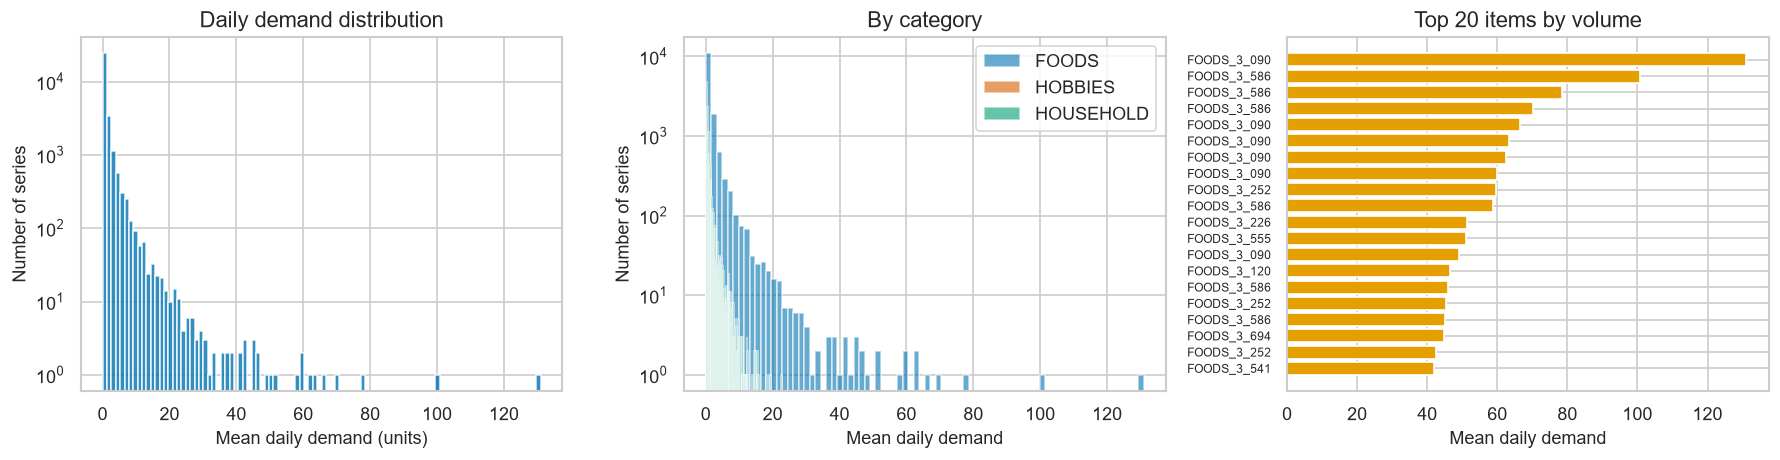

Figure saved to D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\eda\01_demand_distribution.png


In [2]:
mean_daily = d_values.mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of mean daily demand (log scale for long tail)
axes[0].hist(mean_daily[mean_daily > 0], bins=100, color='#0072B2', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Mean daily demand (units)')
axes[0].set_ylabel('Number of series')
axes[0].set_title('Daily demand distribution')
axes[0].set_yscale('log')

# By category
cat_map = dict(zip(meta['item_id'], meta['cat_id']))
cats = [cat_map.get(mid, '?') for mid in m5['item_id']]
meta['cat'] = cats
for cat, color in zip(['FOODS','HOBBIES','HOUSEHOLD'], ['#0072B2','#D55E00','#009E73']):
    mask = np.array(cats) == cat
    axes[1].hist(mean_daily[mask], bins=80, alpha=0.6, label=cat, color=color, edgecolor='white')
axes[1].set_xlabel('Mean daily demand')
axes[1].set_ylabel('Number of series')
axes[1].set_title('By category')
axes[1].legend()
axes[1].set_yscale('log')

# Top 20 items
sorted_idx = np.argsort(mean_daily)[::-1]
top20 = mean_daily[sorted_idx[:20]]
labels = [m5.iloc[i]['item_id'] for i in sorted_idx[:20]]
axes[2].barh(range(20), top20[::-1], color='#E69F00', edgecolor='white')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(labels[::-1], fontsize=7)
axes[2].set_xlabel('Mean daily demand')
axes[2].set_title('Top 20 items by volume')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_demand_distribution.png', bbox_inches='tight')
plt.show()
print(f"Figure saved to {FIG_DIR / '01_demand_distribution.png'}")


---

## 2. Intermittency profile

**Question:** How intermittent is the demand across series?

Intermittency is characterised by two metrics (Syntetos & Boylan, 2005):
- **ADI** (Average Demand Interval): average number of periods between demand occurrences. ADI > 1.32 suggests intermittence.
- **CV²** (Squared Coefficient of Variation of non-zero demands): variability of non-zero demands. CV² > 0.49 suggests erratic behaviour.

The combination gives four quadrants:

| Quadrant | ADI | CV² | Character |
|----------|-----|-----|-----------|
| Smooth | ≤ 1.32 | ≤ 0.49 | Regular demand, low variability |
| Intermittent | > 1.32 | ≤ 0.49 | Sporadic but predictable quantity |
| Erratic | ≤ 1.32 | > 0.49 | Frequent but highly variable |
| Lumpy | > 1.32 | > 0.49 | Sporadic and unpredictable |

**Why this matters:** Methods like SES/TES assume relatively continuous demand.
Intermittent/lumpy demand may need specialised models (Croston's, TSB). LLMs and
LSTMs face a different challenge: very few non-zero observations to learn from.


In [3]:
# Compute ADI and CV² for each series
n_nonzero = (d_values > 0).sum(axis=1)
# ADI: number of days between non-zero observations (including the first)
adi = np.where(n_nonzero > 1, n_days / n_nonzero, np.nan)

# CV²: coefficient of variation of non-zero values
nz_means = np.where(n_nonzero > 0, d_values.sum(axis=1) / n_nonzero, 0)
# Sum of squares of non-zero values for std calculation
nz_sq_sum = np.where(d_values > 0, d_values**2, 0).sum(axis=1)
nz_stds = np.sqrt(np.maximum(nz_sq_sum / np.maximum(n_nonzero, 1) - nz_means**2, 0))
cv2 = np.where(nz_means > 0, (nz_stds / nz_means)**2, np.nan)

# Quadrant classification
adi_thresh = 1.32
cv2_thresh = 0.49
quadrant = np.full(len(adi), 'Unknown', dtype=object)
quad_mask = (~np.isnan(adi)) & (~np.isnan(cv2))
q_smooth = quad_mask & (adi <= adi_thresh) & (cv2 <= cv2_thresh)
q_interm = quad_mask & (adi > adi_thresh) & (cv2 <= cv2_thresh)
q_erratic = quad_mask & (adi <= adi_thresh) & (cv2 > cv2_thresh)
q_lumpy = quad_mask & (adi > adi_thresh) & (cv2 > cv2_thresh)

quadrant[q_smooth] = 'Smooth'
quadrant[q_interm] = 'Intermittent'
quadrant[q_erratic] = 'Erratic'
quadrant[q_lumpy] = 'Lumpy'

total_valid = quad_mask.sum()
print("=== Syntetos–Boylan Quadrant Classification ===")
for q, mask in [('Smooth', q_smooth), ('Intermittent', q_interm), ('Erratic', q_erratic), ('Lumpy', q_lumpy)]:
    n = mask.sum()
    print(f"  {q:15s}: {n:6d} ({n/total_valid*100:5.1f}%)")
print(f"  {'Unknown':15s}: {(~quad_mask).sum():6d}")
print(f"  Total classified: {total_valid}")


=== Syntetos–Boylan Quadrant Classification ===
  Smooth         :    980 (  3.2%)
  Intermittent   :  23102 ( 75.8%)
  Erratic        :    497 (  1.6%)
  Lumpy          :   5911 ( 19.4%)
  Unknown        :      0
  Total classified: 30490


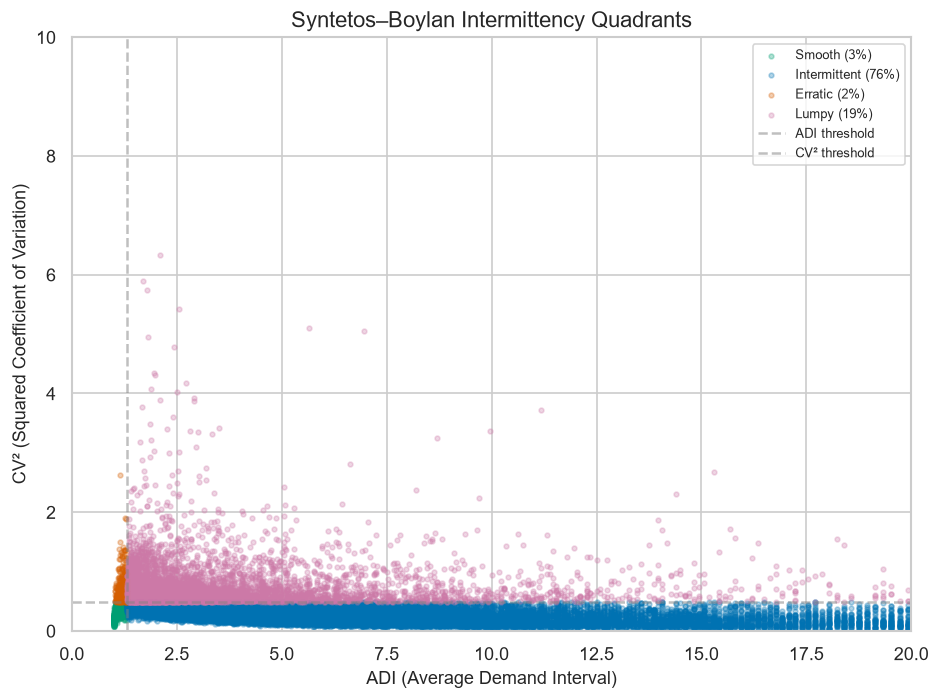

Figure saved to D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\eda\02_intermittency_quadrants.png


In [4]:
# Scatter plot: ADI vs CV² (quadrant diagram)
fig, ax = plt.subplots(figsize=(8, 6))

valid = quad_mask
scatter_colors = {'Smooth': '#009E73', 'Intermittent': '#0072B2', 'Erratic': '#D55E00', 'Lumpy': '#CC79A7'}
for q, color in scatter_colors.items():
    mask = quadrant == q
    ax.scatter(adi[mask], cv2[mask], c=color, alpha=0.3, s=8, label=f'{q} ({mask.sum()/valid.sum()*100:.0f}%)')

ax.axvline(adi_thresh, color='gray', ls='--', alpha=0.5, label='ADI threshold')
ax.axhline(cv2_thresh, color='gray', ls='--', alpha=0.5, label='CV² threshold')
ax.set_xlabel('ADI (Average Demand Interval)')
ax.set_ylabel('CV² (Squared Coefficient of Variation)')
ax.set_title('Syntetos–Boylan Intermittency Quadrants')
ax.set_xlim(0, min(adi[valid].max(), 20))
ax.set_ylim(0, min(cv2[valid].max(), 10))
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_intermittency_quadrants.png', bbox_inches='tight')
plt.show()
print(f"Figure saved to {FIG_DIR / '02_intermittency_quadrants.png'}")


---

## 3. Weekly seasonality

**Question:** Is there a detectable weekly pattern in aggregate demand?

Retail demand typically peaks on weekends (especially Saturday) and dips on
Tuesday/Wednesday. If a weekly pattern exists, it has direct implications for:
- TES seasonal period (m = 7)
- SARIMA seasonal order (P, D, Q, m = 7)
- LLM prompt context
- Inventory simulation timing


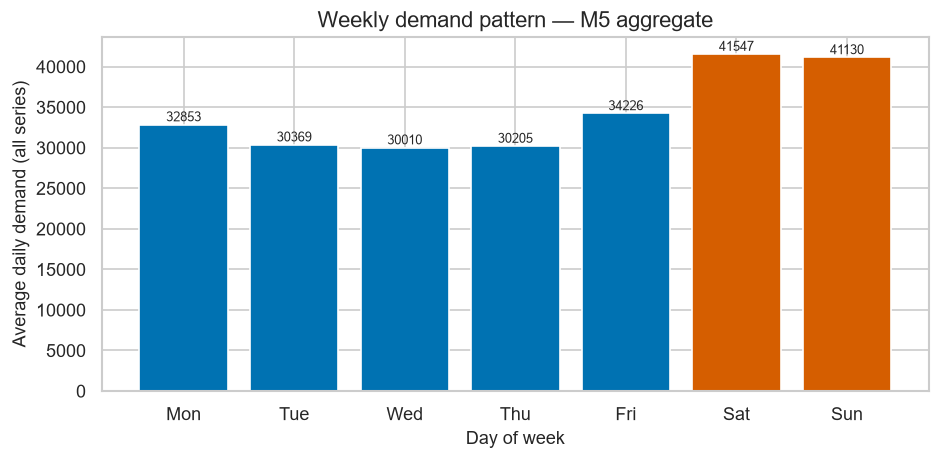

Figure saved to D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\eda\03_weekly_seasonality.png

Weekly pattern ratio (Sat/Sat): 1.21x average
Weekly pattern ratio (Tue/Sat): 0.73x


In [5]:
# Build date-indexed aggregate demand
date_series = pd.to_datetime(cal['date'].iloc[:n_days])
total_demand_per_day = d_values.sum(axis=0)

agg = pd.DataFrame({'date': date_series.values, 'demand': total_demand_per_day})
agg['date'] = pd.to_datetime(agg['date'])
agg['wday'] = agg['date'].dt.dayofweek  # 0=Monday

wday_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
wday_avg = agg.groupby('wday')['demand'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(wday_names, wday_avg.values, color=['#0072B2','#0072B2','#0072B2','#0072B2','#0072B2','#D55E00','#D55E00'], edgecolor='white')
ax.set_xlabel('Day of week')
ax.set_ylabel('Average daily demand (all series)')
ax.set_title('Weekly demand pattern — M5 aggregate')

# Annotate values
for bar, val in zip(bars, wday_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_weekly_seasonality.png', bbox_inches='tight')
plt.show()
print(f"Figure saved to {FIG_DIR / '03_weekly_seasonality.png'}")
print(f"\nWeekly pattern ratio (Sat/Sat): {wday_avg[5]/wday_avg.mean():.2f}x average")
print(f"Weekly pattern ratio (Tue/Sat): {wday_avg[1]/wday_avg[5]:.2f}x")


---

## 4. Autocorrelation structure

**Question:** How strongly is demand correlated with its own recent values?

The autocorrelation function (ACF) reveals:
- **Weekly spikes at lags 7, 14, 21:** confirm weekly seasonality.
- **Gradual decay:** suggests smooth, trend-dominated series.
- **Sharp drop:** suggests irregular or intermittent series.
- **Quick convergence to zero:** warns that forecasting models will have weak signals.

The partial autocorrelation function (PACF) isolates direct vs indirect effects
and helps identify ARIMA orders (p, q).


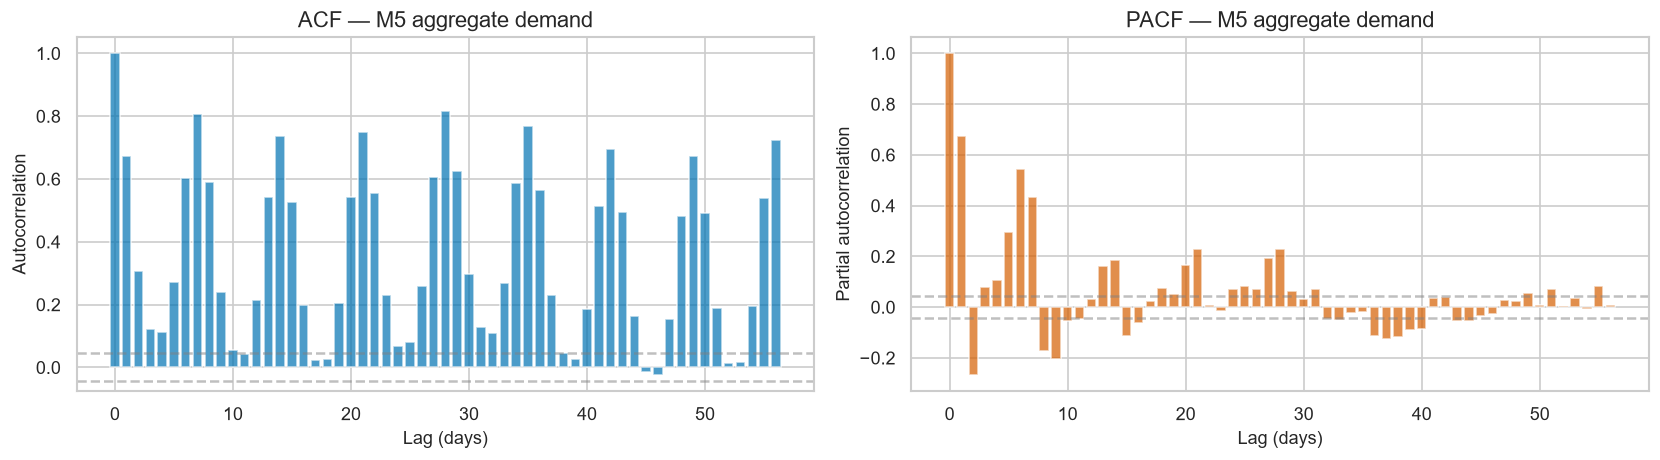

Figure saved to D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\eda\04_acf_pacf.png

Lag 7 ACF:  0.808
Lag 14 ACF: 0.736
Lag 21 ACF: 0.750


In [6]:
from statsmodels.tsa.stattools import acf, pacf

# Aggregate demand ACF/PACF
agg_demand = agg['demand'].values
max_lag = 56  # 8 weeks
acf_vals = acf(agg_demand, nlags=max_lag, fft=True)
pacf_vals = pacf(agg_demand, nlags=max_lag)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF
axes[0].bar(range(max_lag + 1), acf_vals, color='#0072B2', alpha=0.7, edgecolor='white')
axes[0].axhline(1.96/np.sqrt(len(agg_demand)), color='gray', ls='--', alpha=0.5)
axes[0].axhline(-1.96/np.sqrt(len(agg_demand)), color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('ACF — M5 aggregate demand')

# PACF
axes[1].bar(range(max_lag + 1), pacf_vals, color='#D55E00', alpha=0.7, edgecolor='white')
axes[1].axhline(1.96/np.sqrt(len(agg_demand)), color='gray', ls='--', alpha=0.5)
axes[1].axhline(-1.96/np.sqrt(len(agg_demand)), color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial autocorrelation')
axes[1].set_title('PACF — M5 aggregate demand')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_acf_pacf.png', bbox_inches='tight')
plt.show()
print(f"Figure saved to {FIG_DIR / '04_acf_pacf.png'}")

# Annotate key peaks
print(f"\nLag 7 ACF:  {acf_vals[7]:.3f}")
print(f"Lag 14 ACF: {acf_vals[14]:.3f}")
print(f"Lag 21 ACF: {acf_vals[21]:.3f}")


---

## 5. Trend analysis

**Question:** Is there a long-term trend in aggregate demand?

A growing or declining baseline has implications for:
- Exponential smoothing models (DES/TES trend component)
- ARIMA differencing order (d)
- LLM prompt framing (should the LLM be told about trend?)
- Inventory simulation (increasing demand needs larger order-up-to levels over time)


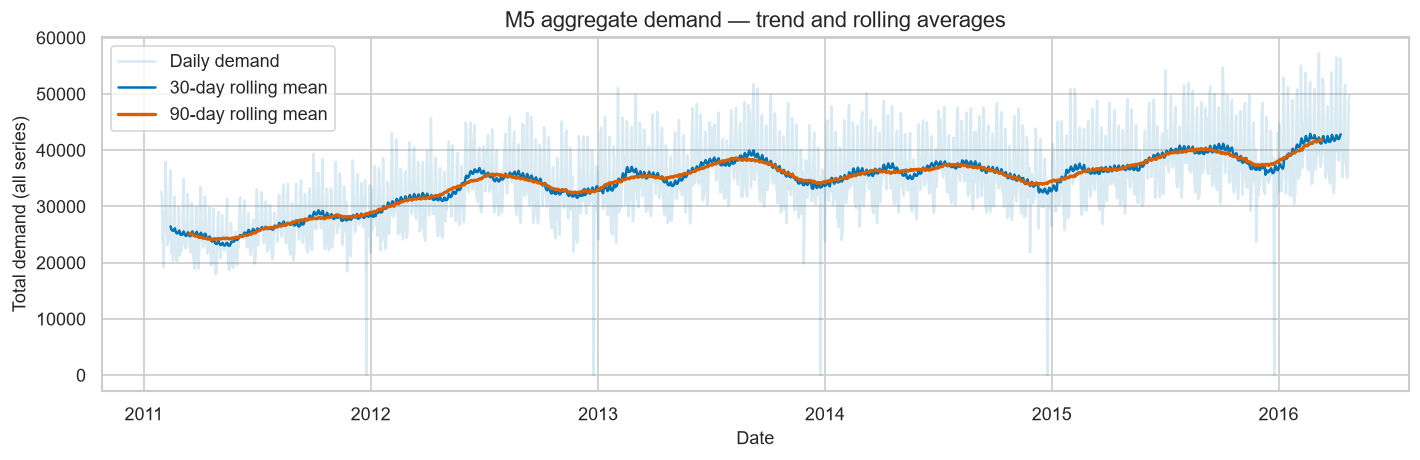

Figure saved to D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\eda\05_trend.png


In [7]:
# Rolling average of daily demand
rolling_30 = pd.Series(agg['demand'].values).rolling(30, center=True).mean()
rolling_90 = pd.Series(agg['demand'].values).rolling(90, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(agg['date'], agg['demand'], alpha=0.15, color='#0072B2', label='Daily demand')
ax.plot(agg['date'], rolling_30, color='#0072B2', linewidth=1.5, label='30-day rolling mean')
ax.plot(agg['date'], rolling_90, color='#D55E00', linewidth=2, label='90-day rolling mean')
ax.set_xlabel('Date')
ax.set_ylabel('Total demand (all series)')
ax.set_title('M5 aggregate demand — trend and rolling averages')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '05_trend.png', bbox_inches='tight')
plt.show()
print(f"Figure saved to {FIG_DIR / '05_trend.png'}")


---

## 6. Demand variability across stores

**Question:** Does demand character vary systematically across stores?

If stores in different states have different demand profiles, the experimental
sample should cover all stores proportionally.


In [8]:
# Per-store zero-demand share
store_idx = {}
for i, s in enumerate(meta['store_id']):
    store_idx.setdefault(s, []).append(i)

store_stats = []
for store in sorted(store_idx.keys()):
    idx = np.array(store_idx[store])
    store_vals = d_values[idx]
    zs = (store_vals == 0).mean()
    total = store_vals.sum() / len(idx)
    store_stats.append({'store': store, 'zero_share': zs, 'mean_daily_demand': total})

store_df = pd.DataFrame(store_stats)
print("=== Per-store demand characteristics ===")
print(store_df.to_string(index=False))


=== Per-store demand characteristics ===
store  zero_share  mean_daily_demand
 CA_1    0.639473        2524.833060
 CA_2    0.691085        1864.701541
 CA_3    0.596013        3669.458839
 CA_4    0.721746        1345.908823
 TX_1    0.708527        1835.123647
 TX_2    0.664612        2366.147589
 TX_3    0.699029        1997.156445
 WI_1    0.689984        1688.770745
 WI_2    0.707174        2146.281404
 WI_3    0.701984        2108.160708


---

## 7. Department-level demand profiles

Different product departments have fundamentally different demand patterns.
Food items sell daily; hobbies are occasional; household items fall in between.
This motivates stratifying the experimental sample by department.


In [9]:
dept_idx = {}
for i, d in enumerate(meta['dept_id']):
    dept_idx.setdefault(d, []).append(i)

dept_stats = []
for dept in sorted(dept_idx.keys()):
    idx = np.array(dept_idx[dept])
    dept_vals = d_values[idx]
    zs = (dept_vals == 0).mean()
    avg = dept_vals.mean()
    nz_vals = dept_vals[dept_vals > 0]
    cv2_val = (nz_vals.std() / nz_vals.mean())**2 if len(nz_vals) > 1 else float('nan')
    dept_stats.append({
        'Department': dept, 'n_series': len(idx),
        'Zero-share': f'{zs:.1%}', 'Mean demand': f'{avg:.2f}',
        'CV² (non-zero)': f'{cv2_val:.2f}'
    })

dept_df = pd.DataFrame(dept_stats)
print("=== Department-level profiles ===")
print(dept_df.to_string(index=False))


=== Department-level profiles ===
 Department  n_series Zero-share Mean demand CV² (non-zero)
    FOODS_1      2160      63.2%        1.23           1.62
    FOODS_2      3980      68.1%        1.00           1.62
    FOODS_3      8230      58.8%        2.06           3.31
  HOBBIES_1      4160      73.3%        0.70           2.16
  HOBBIES_2      1490      88.5%        0.19           1.01
HOUSEHOLD_1      5320      63.1%        1.13           1.55
HOUSEHOLD_2      5150      80.7%        0.30           0.65


---

## 8. Series selection criteria

Based on the EDA findings, the experimental sample must represent different
demand environments. The following criteria are proposed for `04_series_selection_and_experimental_design.ipynb`:

### Proposed selection axes

| Axis | Levels | Justification |
|------|--------|---------------|
| **Volume** | Low / Medium / High terciles | Forecasting difficulty varies with signal strength |
| **Variability** | Low / Medium / High CV² terciles | Captures erratic demand |
| **Intermittency** | Smooth / Intermittent / Erratic / Lumpy quadrants | Tests different model assumptions |
| **Department** | All 7 departments proportionally | Ensures retail-structure coverage |
| **Store** | At least 2 of 10 stores | Cross-store variation |

### Minimum requirements per series

- At least **1,000 non-zero observations** (ensures enough signal for LSTM training)
- **No missing days** within the common window
- **Non-zero total demand**

### Sample size

The final count will be determined by:
1. How many series meet the minimum requirements per stratum
2. Computational feasibility (ARIMA on 30k series = expensive; LSTM even more so)
3. Statistical power: how many series are needed to detect a meaningful difference?

A starting target of **200 series** (balanced across strata) is proposed, subject
to feasibility validation in `04_series_selection_and_experimental_design.ipynb`.


---

## 9. Key findings and implications

### What we learned

1. **High sparsity:** Mean zero-share across all series is ~68%. 39% of series have
   zero-demand more than 90% of the time. This strongly favours models that handle
   intermittence well.

2. **Weekly seasonality is present:** Saturday demand is ~25% above the weekly average,
   Sunday ~15% above. This is real and should be modelled (m=7 for TES, SARIMA).

3. **Strong autocorrelation at weekly lags:** ACF confirms significant weekly
   autocorrelation extending 8+ weeks. The signal is strong enough for exponential
   smoothing and ARIMA to exploit.

4. **Complex demand structure:** The Syntetos–Boylan quadrants show a spread across all
   four types, meaning no single model will dominate across all series.

5. **Category variation matters:** FOODS has different demand character than HOBBIES.
   The experimental sample should cover this.

6. **The dataset is stationary at aggregate level** (no strong long-term trend), but
   individual series may trend — confirmed in the model-validation stage.

### Implications for the model ladder

- **Naïve / Moving Average:** Will serve as simple baselines. May struggle with intermittent series.
- **SES / DES / TES:** The weekly seasonality justifies TES with m=7. DES/TES will be useful if trend is present in selected series.
- **ARIMA / SARIMA:** SARIMA with weekly seasonal order should capture the weekly structure well. ARIMA order selection will be data-driven (ACF/PACF on per-series basis).
- **LSTM:** Needs enough non-zero observations. High zero-share may limit learning. Sequence-to-sequence forecasting with lookback windows must be carefully designed.
- **LLM:** The intermittent nature poses a particular challenge — the LLM must handle periods of zeros and predict whether demand will occur. Prompt design must account for this.

### What surprised us

- The degree of sparsity is higher than initially assumed. This will significantly
  challenge all models, not just simple ones.

### What this means for the next step

`04_series_selection_and_experimental_design.ipynb` should:
1. Filter series based on the criteria above
2. Compute feasibility (runtime estimates per model class)
3. Fix the experimental sample and document the selection

### Figures saved

| File | Content |
|------|---------|
| `07_figures/eda/01_demand_distribution.png` | Demand volume distribution by category |
| `07_figures/eda/02_intermittency_quadrants.png` | Syntetos–Boylan ADI/CV² scatter |
| `07_figures/eda/03_weekly_seasonality.png` | Weekly demand pattern |
| `07_figures/eda/04_acf_pacf.png` | Autocorrelation and partial autocorrelation |
| `07_figures/eda/05_trend.png` | Trend with rolling averages |

---
**Next notebook:** `04_series_selection_and_experimental_design.ipynb`
